# Fase 2: Formulación de hipótesis

Proyecto: Análisis BI Airbnb NYC - Equipo 10

Este notebook ejecuta las pruebas estadísticas para validar o rechazar las hipótesis planteadas en el documento `docs/fase2_hipotesis.md`. Se usa un nivel de significancia de α = 0.05 en todas las pruebas.

In [16]:
# Importamos las librerías que vamos a usar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, levene

# Configuración visual
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)

# Cargamos el dataset original y aplicamos una limpieza mínima para poder correr los tests:
# Se eliminan registros con price = 0.
# Se filtran valores atípico extremos de precio > $1000.
# Se eliminan nulos en las columnas que vamos a usar.

# Cargar dataset
df = pd.read_csv('../data/raw/AB_NYC_2019.csv')

print(f"Registros originales: {df.shape[0]:,}")

# Limpieza mínima para los tests
df = df[df['price'] > 0]
df = df[df['price'] < 1000]

print(f"Registros después de limpieza mínima: {df.shape[0]:,}")
df.head()

Registros originales: 48,895
Registros después de limpieza mínima: 48,586


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## Hipótesis 1: Diferencia de precios entre distritos

H0: El precio promedio por noche es igual en los 5 distritos.  
H1: Al menos un distrito tiene un precio promedio significativamente diferente.

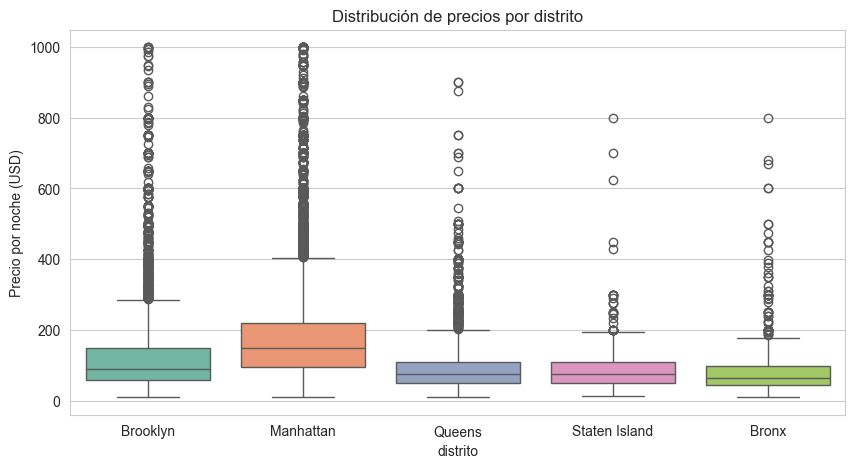

VALIDACIÓN DE SUPUESTOS

Test de normalidad (Shapiro-Wilk)
Bronx: p-value = 0.0000
Brooklyn: p-value = 0.0000
Manhattan: p-value = 0.0000
Queens: p-value = 0.0000
Staten Island: p-value = 0.0000

Test de homogeneidad de varianzas (Levene)
p-value = 0.0000

Resultados ANOVA
Estadístico F: 1208.3010
Valor p: 0.0000e+00

Resultados Kruskal-Wallis
Estadístico H: 6942.9169
Valor p: 0.0000e+00
DECISIÓN

Los supuestos de ANOVA no se cumplen completamente.
Se toma como referencia el test no paramétrico (Kruskal-Wallis).

Con Kruskal-Wallis: Se rechaza H0 (p = 0.0000e+00 < 0.05)
   → Existen diferencias significativas en los precios entre distritos.


In [15]:
# Estadísticas descriptivas por distritos
df.groupby('neighbourhood_group')['price'].describe().round(2)

# Visualización: boxplot de precios por distritos
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df,
    x='neighbourhood_group',
    y='price',
    hue='neighbourhood_group',
    palette='Set2',
    legend=False
)
plt.title('Distribución de precios por distrito')
plt.xlabel('distrito')
plt.ylabel('Precio por noche (USD)')
plt.show()

# Agrupamos los precios por distrito
manhattan = df[df['neighbourhood_group']=='Manhattan']['price']
brooklyn = df[df['neighbourhood_group']=='Brooklyn']['price']
queens = df[df['neighbourhood_group']=='Queens']['price']
bronx = df[df['neighbourhood_group']=='Bronx']['price']
staten = df[df['neighbourhood_group']=='Staten Island']['price']

# Nivel de significancia
alpha = 0.05

# Validación de supuestos
print("VALIDACIÓN DE SUPUESTOS")

# Test de normalidad (Shapiro-Wilk)
print("\nTest de normalidad (Shapiro-Wilk)")
for name, group in df.groupby('neighbourhood_group'):
    sample = group['price'].dropna()
    if len(sample) > 500:
        sample = sample.sample(500, random_state=42)
    stat, p = shapiro(sample)
    print(f"{name}: p-value = {p:.4f}")

# Test de homogeneidad de varianzas (Levene)
print("\nTest de homogeneidad de varianzas (Levene)")
stat_levene, p_levene = levene(manhattan, brooklyn, queens, bronx, staten)
print(f"p-value = {p_levene:.4f}")

# Test ANOVA
f_stat, p_value_anova = stats.f_oneway(manhattan, brooklyn, queens, bronx, staten)
print("\nResultados ANOVA")
print(f"Estadístico F: {f_stat:.4f}")
print(f"Valor p: {p_value_anova:.4e}")

# Test Kruskal-Wallis (no paramétrico)
h_stat, p_value_kw = stats.kruskal(manhattan, brooklyn, queens, bronx, staten)
print("\nResultados Kruskal-Wallis")
print(f"Estadístico H: {h_stat:.4f}")
print(f"Valor p: {p_value_kw:.4e}")

# Decisión final
print("DECISIÓN")

cumple_levene = p_levene > alpha

if cumple_levene:
    print("\nLos supuestos de homogeneidad de varianzas SÍ se cumplen.")
    print("Se puede confiar en los resultados de ANOVA.\n")
    p_final = p_value_anova
    test_usado = "ANOVA"
else:
    print("\nLos supuestos de ANOVA no se cumplen completamente.")
    print("Se toma como referencia el test no paramétrico (Kruskal-Wallis).\n")
    p_final = p_value_kw
    test_usado = "Kruskal-Wallis"

if p_final < alpha:
    print(f"Con {test_usado}: Se rechaza H0 (p = {p_final:.4e} < {alpha})")
    print("   → Existen diferencias significativas en los precios entre distritos.")
else:
    print(f"Con {test_usado}: No se rechaza H0 (p = {p_final:.4e} > {alpha})")



## Hipótesis 2: Diferencia de precios entre tipos de habitación

H0: El precio promedio por noche es igual entre los distintos tipos de habitación (Entire home/apt, Private room, Shared room).  
H1: Al menos un tipo de habitación tiene un precio promedio significativamente diferente.

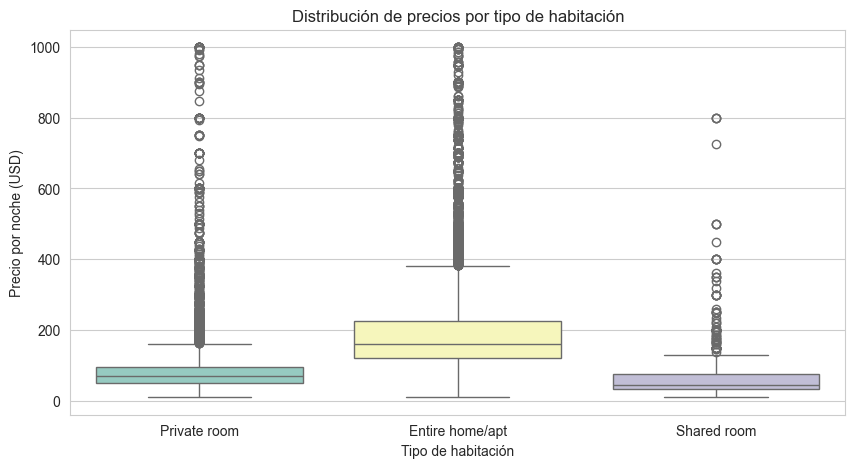

VALIDACIÓN DE SUPUESTOS

Test de normalidad (Shapiro-Wilk)
Entire home/apt: p-value = 0.0000
Private room: p-value = 0.0000
Shared room: p-value = 0.0000

Test de homogeneidad de varianzas (Levene)
p-value = 0.0000
APLICACIÓN DE PRUEBAS ESTADÍSTICAS

Resultados ANOVA
Estadístico F: 7442.1571
Valor p: 0.0000e+00

Resultados Kruskal-Wallis
Estadístico H: 22408.0847
Valor p: 0.0000e+00
DECISIÓN FINAL - HIPÓTESIS 2

Los supuestos de ANOVA no se cumplen completamente.
Se toma como referencia el test no paramétrico (Kruskal-Wallis).

Con Kruskal-Wallis: Se rechaza H0 (p = 0.0000e+00 < 0.05)
   → Existen diferencias significativas en los precios entre tipos de habitación.


In [17]:
# Estadísticas descriptivas por tipo de habitación
df.groupby('room_type')['price'].describe().round(2)

# Visualización: boxplot de precios por tipo de habitación
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df,
    x='room_type',
    y='price',
    hue='room_type',
    palette='Set3',
    legend=False
)
plt.title('Distribución de precios por tipo de habitación')
plt.xlabel('Tipo de habitación')
plt.ylabel('Precio por noche (USD)')
plt.show()

# Agrupamos precios por tipo de habitación
entire = df[df['room_type']=='Entire home/apt']['price']
private = df[df['room_type']=='Private room']['price']
shared = df[df['room_type']=='Shared room']['price']

print("VALIDACIÓN DE SUPUESTOS")

# Test de normalidad (Shapiro-Wilk)
print("\nTest de normalidad (Shapiro-Wilk)")
for name, group in df.groupby('room_type'):
    sample = group['price'].dropna()
    if len(sample) > 500:
        sample = sample.sample(500, random_state=42)
    stat, p = shapiro(sample)
    print(f"{name}: p-value = {p:.4f}")

# Test de homogeneidad de varianzas (Levene)
print("\nTest de homogeneidad de varianzas (Levene)")
stat_levene, p_levene = levene(entire, private, shared)
print(f"p-value = {p_levene:.4f}")

# === Aplicación de tests ===
print("APLICACIÓN DE PRUEBAS ESTADÍSTICAS")

# Test ANOVA
f_stat, p_value_anova = stats.f_oneway(entire, private, shared)
print("\nResultados ANOVA")
print(f"Estadístico F: {f_stat:.4f}")
print(f"Valor p: {p_value_anova:.4e}")

# Test Kruskal-Wallis (no paramétrico)
h_stat, p_value_kw = stats.kruskal(entire, private, shared)
print("\nResultados Kruskal-Wallis")
print(f"Estadístico H: {h_stat:.4f}")
print(f"Valor p: {p_value_kw:.4e}")

# === Decisión final ===
print("DECISIÓN FINAL - HIPÓTESIS 2")

cumple_levene = p_levene > alpha

if cumple_levene:
    print("\nLos supuestos de homogeneidad de varianzas SÍ se cumplen.")
    print("Se puede confiar en los resultados de ANOVA.\n")
    p_final = p_value_anova
    test_usado = "ANOVA"
else:
    print("\nLos supuestos de ANOVA no se cumplen completamente.")
    print("Se toma como referencia el test no paramétrico (Kruskal-Wallis).\n")
    p_final = p_value_kw
    test_usado = "Kruskal-Wallis"

if p_final < alpha:
    print(f"Con {test_usado}: Se rechaza H0 (p = {p_final:.4e} < {alpha})")
    print("   → Existen diferencias significativas en los precios entre tipos de habitación.")
else:
    print(f"Con {test_usado}: No se rechaza H0 (p = {p_final:.4e} > {alpha})")

## Hipótesis 3: Desempeño de anfitriones profesionales vs ocasionales

H0: No hay diferencia en el número de reseñas entre los anfitriones con una sola propiedad y los que tienen múltiples propiedades.  
H1: Los anfitriones con múltiples propiedades tienen en promedio un número de reseñas diferente al de los anfitriones ocasionales.


Distribución de tipos de anfitrión:
host_type
Ocasional      32091
Profesional    16495
Name: count, dtype: int64

Porcentaje:
host_type
Ocasional      66.05
Profesional    33.95
Name: proportion, dtype: float64


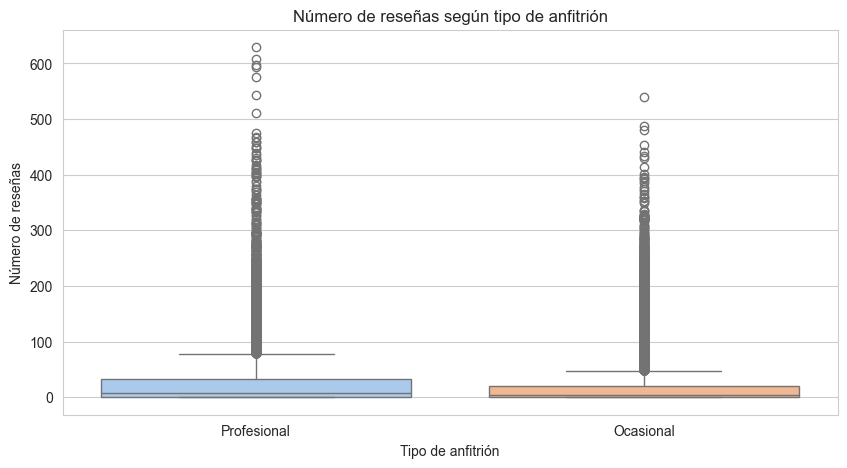

VALIDACIÓN DE SUPUESTOS

Test de normalidad (Shapiro-Wilk)
Ocasional: p-value = 0.0000
Profesional: p-value = 0.0000

Test de homogeneidad de varianzas (Levene)
p-value = 0.0000
APLICACIÓN DE PRUEBAS ESTADÍSTICAS

Resultados T-test de Welch
Estadístico t: -18.2919
Valor p: 2.6873e-74

Resultados Mann-Whitney U
Estadístico U: 234786039.0000
Valor p: 1.4397e-93

DECISIÓN FINAL - HIPÓTESIS 3

Los supuestos paramétricos no se cumplen completamente.
Se toma como referencia el test no paramétrico (Mann-Whitney U).

Con Mann-Whitney U: Se rechaza H0 (p = 1.4397e-93 < 0.05)
   → Existe una diferencia significativa en el número de reseñas
     entre anfitriones ocasionales y profesionales.

Comparación de medias
Ocasional: 20.51 reseñas en promedio
Profesional: 28.94 reseñas en promedio

→ Los anfitriones PROFESIONALES tienen más reseñas en promedio.


In [23]:
# Creamos la variable host_type a partir de calculated_host_listings_count
df['host_type'] = df['calculated_host_listings_count'].apply(
    lambda x: 'Profesional' if x > 1 else 'Ocasional'
)

# Distribución de cada grupo
print("Distribución de tipos de anfitrión:")
print(df['host_type'].value_counts())
print(f"\nPorcentaje:")
print((df['host_type'].value_counts(normalize=True) * 100).round(2))

# Estadísticas descriptivas del número de reseñas por tipo de anfitrión
df.groupby('host_type')['number_of_reviews'].describe().round(2)

# Visualización: boxplot de reseñas por tipo de anfitrión
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df,
    x='host_type',
    y='number_of_reviews',
    hue='host_type',
    palette='pastel',
    legend=False
)
plt.title('Número de reseñas según tipo de anfitrión')
plt.xlabel('Tipo de anfitrión')
plt.ylabel('Número de reseñas')
plt.show()

# Separamos los grupos
ocasional = df[df['host_type']=='Ocasional']['number_of_reviews']
profesional = df[df['host_type']=='Profesional']['number_of_reviews']

print("VALIDACIÓN DE SUPUESTOS")

# Test de normalidad (Shapiro-Wilk)
print("\nTest de normalidad (Shapiro-Wilk)")
for name, group in df.groupby('host_type'):
    sample = group['number_of_reviews'].dropna()
    if len(sample) > 500:
        sample = sample.sample(500, random_state=42)
    stat, p = shapiro(sample)
    print(f"{name}: p-value = {p:.4f}")

# Test de homogeneidad de varianzas (Levene)
print("\nTest de homogeneidad de varianzas (Levene)")
stat_levene, p_levene = levene(ocasional, profesional)
print(f"p-value = {p_levene:.4f}")

# Aplicación de tests 
print("APLICACIÓN DE PRUEBAS ESTADÍSTICAS")

# T-test de Welch
t_stat, p_value_t = stats.ttest_ind(ocasional, profesional, equal_var=False)
print("\nResultados T-test de Welch")
print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p: {p_value_t:.4e}")

# Mann-Whitney U (no paramétrico)
u_stat, p_value_mw = stats.mannwhitneyu(ocasional, profesional, alternative='two-sided')
print("\nResultados Mann-Whitney U")
print(f"Estadístico U: {u_stat:.4f}")
print(f"Valor p: {p_value_mw:.4e}")

# Decisión final
print("\nDECISIÓN FINAL - HIPÓTESIS 3")

cumple_levene = p_levene > alpha

if cumple_levene:
    print("\nLos supuestos de homogeneidad de varianzas SÍ se cumplen.")
    print("Se puede confiar en los resultados del T-test de Welch.\n")
    p_final = p_value_t
    test_usado = "T-test de Welch"
else:
    print("\nLos supuestos paramétricos no se cumplen completamente.")
    print("Se toma como referencia el test no paramétrico (Mann-Whitney U).\n")
    p_final = p_value_mw
    test_usado = "Mann-Whitney U"

if p_final < alpha:
    print(f"Con {test_usado}: Se rechaza H0 (p = {p_final:.4e} < {alpha})")
    print("   → Existe una diferencia significativa en el número de reseñas")
    print("     entre anfitriones ocasionales y profesionales.")
else:
    print(f"Con {test_usado}: No se rechaza H0 (p = {p_final:.4e} > {alpha})")

# Mostrar qué grupo tiene más reseñas en promedio
print("\nComparación de medias")
print(f"Ocasional: {ocasional.mean():.2f} reseñas en promedio")
print(f"Profesional: {profesional.mean():.2f} reseñas en promedio")

if ocasional.mean() > profesional.mean():
    print("\n→ Los anfitriones OCASIONALES tienen más reseñas en promedio.")
else:
    print("\n→ Los anfitriones PROFESIONALES tienen más reseñas en promedio.")

